In [1]:
import sys
sys.path.insert(0, '../')

from src.load_data import PatientLoader
from src.process import NeuroFeatureExtractor

## Import Data

In [2]:
from nilearn import plotting, image, masking
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "data/sub-2004"
loader = PatientLoader()
recording = loader.load(file_path)

### Correlation Matrix --> a partir de atlas

Fetching Schaefer Atlas (200 ROIs)...
[fetch_atlas_schaefer_2018] Dataset found in C:\Users\ainho\nilearn_data\schaefer_2018
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ainho\nilearn_data\fsl
[NiftiLabelsMasker.wrapped] loading data from Nifti1Image(
shape=(91, 109, 91),
affine=array([[   2.,    0.,    0.,  -90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])
)


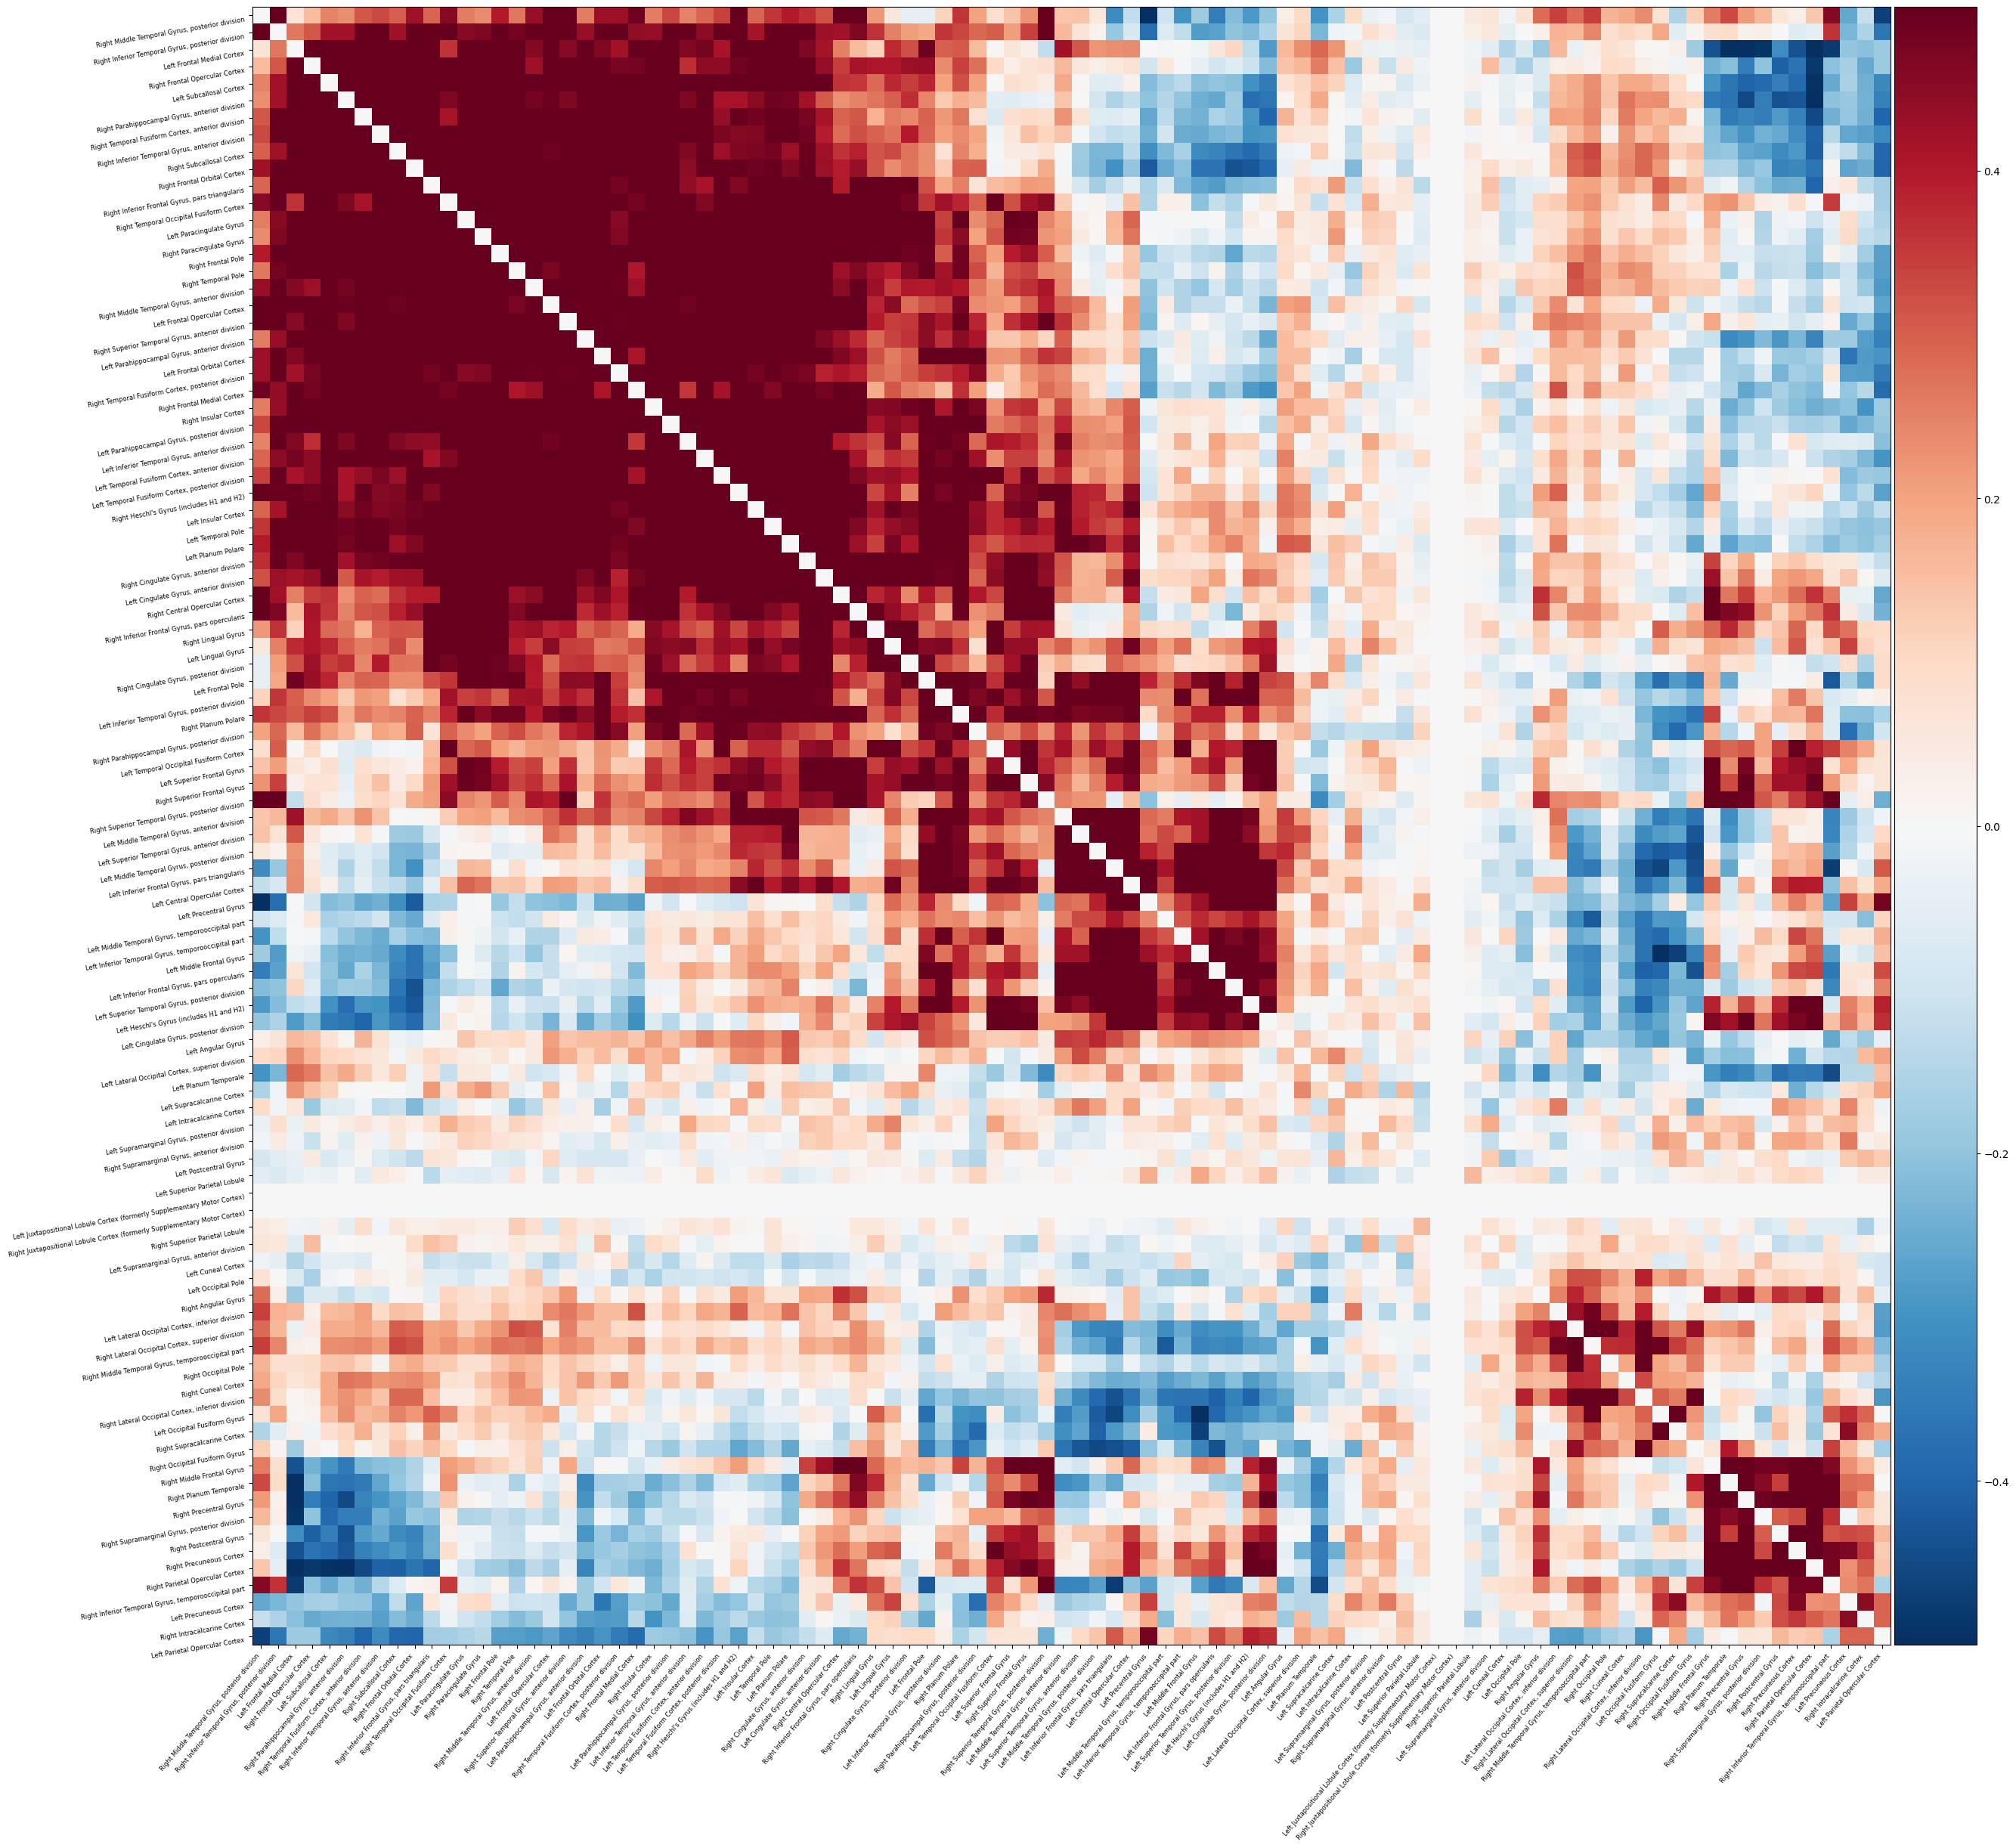

In [4]:
extractor = NeuroFeatureExtractor()

matrix = extractor.extract_functional_connectivity(recording,  we_plot=True)

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ainho\nilearn_data\fsl


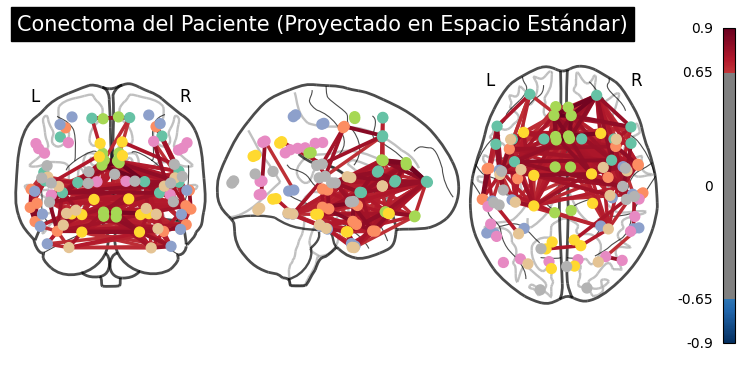

In [12]:
from nilearn import datasets

atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm', symmetric_split=True)
atlas_filename = atlas.maps

atlas_native = image.resample_to_img(
    source_img=atlas_filename,
    target_img=recording.func.img,
    interpolation='nearest',
    force_resample=True,  
    copy_header=True      
)
atlas_data = atlas_native.get_fdata()
present_ids = np.unique(atlas_data)
present_ids = present_ids[present_ids != 0].astype(int)


coords_mni_completas = plotting.find_parcellation_cut_coords(atlas_filename)

plotting.plot_connectome(
    adjacency_matrix=matrix,
    node_coords=coords_mni_completas,
    edge_threshold='95%',               
    title="Conectoma del Paciente (Proyectado en Espacio Estándar)"
)

plotting.show()